In [63]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import yfinance as yf 

In [65]:
# Read training and test datasets


def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
    df.set_index('Date', inplace=True)
    return df

def add_all_derived_features(df):
    # Create target variable (next day's close price)
    df['Target'] = df['Close'].shift(-1)

    # Create additional derived features
    df['MA_5'] = df['Close'].rolling(window=5).mean() # 5-day Moving Average
    df['MA_20'] = df['Close'].rolling(window=20).mean()# 20-day Moving Average
    df['Range'] = df['High'] - df['Low'] # Daily High - Low
    df['High_Close_Ratio'] = (df['High'] - df['Close']) / (df['Close'] + 1e-9) # (High - Close) / Close 
    df['Close_Low_Ratio'] = (df['Close'] - df['Low']) / (df['Close'] + 1e-9) # (Close - Low) / Close
    df['Volume_Change'] = df['Volume'].pct_change().fillna(0) # Volume change percentage (fill NaN for the first day with 0)


    # Handle missing values at the beginning/end generated during feature creation
    # Fill NaNs at the beginning for Moving Averages etc. with ffill
    df['MA_5'] = df['MA_5'].ffill()
    df['MA_20'] = df['MA_20'].ffill()
    # Target variable gets NaN in the last row due to shift(-1)
    # The first row of Volume_Change becomes NaN due to pct_change(), so fillna(0) is applied

    return df

df_train_raw = read_data('/Users/jeonginn/Desktop/ML/kospi_train.csv')
df_test_raw = read_data('/Users/jeonginn/Desktop/ML/kospi_test.csv')

print("Original KOSPI Train Data Loaded. Shape:", df_train_raw.shape)
print("Original KOSPI Test Data Loaded. Shape:", df_test_raw.shape)



Original KOSPI Train Data Loaded. Shape: (986, 5)
Original KOSPI Test Data Loaded. Shape: (244, 5)


In [66]:
# Part 1: Modeling using Basic and Selected Derived Features


print("\n--- Starting Part 1: Basic + Selected Derived Features ---")

# Prepare Part 1 training data
df_train_part1 = df_train_raw.copy()
df_train_part1 = add_all_derived_features(df_train_part1)

# Define the final list of features to use in Part 1 (Original 5 + MA_5)
features_part1 = ['Open', 'Low', 'High', 'Close', 'Volume', 'MA_5']

# Keep only the rows that are finally needed, including those where NaN occurred in the last row due to target variable creation
# Some NaNs for Target and MA_5/MA_20 etc. were handled in add_all_derived_features.
# Here, only the NaN in the last row caused by Target needs to be removed.
df_train_part1_final = df_train_part1.dropna(subset=features_part1 + ['Target']).copy() 

X_train_part1 = df_train_part1_final[features_part1]
y_train_part1 = df_train_part1_final['Target']

# Prepare Part 1 test data
df_test_part1 = df_test_raw.copy() 
df_test_part1 = add_all_derived_features(df_test_part1) # Generate all derived features

# Test data uses the same feature list as training data
# Remove only the NaN in the last row caused by Target
df_test_part1_final = df_test_part1.dropna(subset=features_part1 + ['Target']).copy() 

X_test_part1 = df_test_part1_final[features_part1]
y_test_part1 = df_test_part1_final['Target']

print(f"Part 1 X_train shape: {X_train_part1.shape}, y_train shape: {y_train_part1.shape}")
print(f"Part 1 X_test shape: {X_test_part1.shape}, y_test shape: {y_test_part1.shape}")


# Feature Scaling (fit on Part 1 train data, transform train/test)scaler_part1 = StandardScaler()
X_train_part1_scaled = scaler_part1.fit_transform(X_train_part1)
X_test_part1_scaled = scaler_part1.transform(X_test_part1)


# Model Definition and Hyperparameter Tuning (Part 1)
print("\nPart 1 Model Training & Cross-Validation:")
models_part1 = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

# Random Forest Hyperparameter Tuning
rf_param_grid_part1 = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}
rf_grid_part1 = GridSearchCV(models_part1["RandomForest"], rf_param_grid_part1, cv=TimeSeriesSplit(n_splits=3),scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid_part1.fit(X_train_part1_scaled, y_train_part1)
best_rf_part1 = rf_grid_part1.best_estimator_
print(f"Part 1 Best Random Forest Params: {rf_grid_part1.best_params_}")

# XGBoost Hyperparameter Tuning
xgb_param_grid_part1 = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.05]
}
xgb_grid_part1 = GridSearchCV(models_part1["XGBoost"], xgb_param_grid_part1, cv=TimeSeriesSplit(n_splits=3),scoring='neg_mean_squared_error', n_jobs=-1)
xgb_grid_part1.fit(X_train_part1_scaled, y_train_part1)
best_xgb_part1 = xgb_grid_part1.best_estimator_
print(f"Part 1 Best XGBoost Params: {xgb_grid_part1.best_params_}")


# Store Cross-Validation Results (using optimally tuned models)
models_part1_tuned = {
    "LinearRegression": LinearRegression(),
    "RandomForest": best_rf_part1,
    "XGBoost": best_xgb_part1
}

tscv_part1 = TimeSeriesSplit(n_splits=5) # Final CV is set to 5 folds
results_part1_cv = {}

print("\nPart 1 Cross-Validation Results (RMSE):")
for name, model in models_part1_tuned.items():
    rmses = []
    # TimeSeriesSplit object should be created new each time or split() results stored in a list
    # for train_idx, val_idx in TimeSeriesSplit(n_splits=5).split(X_train_part1_scaled):
    for fold, (train_idx, val_idx) in enumerate(tscv_part1.split(X_train_part1_scaled)):
        X_train, X_val = X_train_part1_scaled[train_idx], X_train_part1_scaled[val_idx]
        y_train, y_val = y_train_part1.iloc[train_idx], y_train_part1.iloc[val_idx] # pandas Series는 .iloc 사용

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = mean_squared_error(y_val, preds, squared=False)
        rmses.append(rmse)
        print(f"  {name} - Fold {fold+1}: RMSE = {rmse:.2f}")
    
    results_part1_cv[name] = {
        "mean_rmse": np.mean(rmses),
        "std_rmse": np.std(rmses)
    }
    print(f"  {name}: Avg RMSE = {results_part1_cv[name]['mean_rmse']:.2f} ± {results_part1_cv[name]['std_rmse']:.2f}")

# Select Best Model for Part 1 (based on average RMSE)
best_model_part1_name = min(results_part1_cv, key=lambda k: results_part1_cv[k]['mean_rmse'])
best_model_part1 = models_part1_tuned[best_model_part1_name]
print(f"\nPart 1 Best Model (based on CV): {best_model_part1_name}")


# Final Prediction and Evaluation on Test Data with Part 1 Best Model
print("\nPart 1 Final Evaluation on Test Data:")
best_model_part1.fit(X_train_part1_scaled, y_train_part1)
predictions_part1 = best_model_part1.predict(X_test_part1_scaled)
rmse_part1_test = mean_squared_error(y_test_part1, predictions_part1, squared=False)
print(f"Part 1 Test Data RMSE ({best_model_part1_name}): {rmse_part1_test:.2f}")

# Add prediction result column to test data (using .loc to prevent warning)
df_test_part1_final.loc[:, 'Predicted_Close_Part1'] = predictions_part1
print("\nPart 1 Test Data Predictions (Head):")
print(df_test_part1_final[['Close', 'Predicted_Close_Part1']].head())




--- Starting Part 1: Basic + Selected Derived Features ---
Part 1 X_train shape: (981, 6), y_train shape: (981,)
Part 1 X_test shape: (239, 6), y_test shape: (239,)

Part 1 Model Training & Cross-Validation:
Part 1 Best Random Forest Params: {'max_depth': 10, 'n_estimators': 100}
Part 1 Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Part 1 Cross-Validation Results (RMSE):
  LinearRegression - Fold 1: RMSE = 32.49
  LinearRegression - Fold 2: RMSE = 36.66
  LinearRegression - Fold 3: RMSE = 33.61
  LinearRegression - Fold 4: RMSE = 29.42
  LinearRegression - Fold 5: RMSE = 28.55
  LinearRegression: Avg RMSE = 32.15 ± 2.93
  RandomForest - Fold 1: RMSE = 96.43
  RandomForest - Fold 2: RMSE = 246.72
  RandomForest - Fold 3: RMSE = 210.10
  RandomForest - Fold 4: RMSE = 51.89
  RandomForest - Fold 5: RMSE = 39.12
  RandomForest: Avg RMSE = 128.85 ± 84.29
  XGBoost - Fold 1: RMSE = 96.93
  XGBoost - Fold 2: RMSE = 236.64
  XGBoost - Fold 3: RMSE = 221.84


In [60]:
# Part 2: Modeling using External Data and All Derived Features

print("\n--- Starting Part 2: External + All Derived Features ---")

# Prepare Part 2 data (using full training and test periods)
start_date_full = df_train_raw.index.min().strftime('%Y-%m-%d')
end_date_full = df_test_raw.index.max().strftime('%Y-%m-%d')
end_date_full_yf = (df_test_raw.index.max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d') # yfinance end date 보정

# Fetch external data
print("Fetching external data for the full period...")
sp500_data_full = yf.download('^GSPC', start=start_date_full, end=end_date_full_yf, progress=False)
krw_usd_data_full = yf.download('KRW=X', start=start_date_full, end=end_date_full_yf, progress=False)

# Preprocess and merge external data (merge into original train/test DataFrames respectively)
# Select and rename columns (using MultiIndex access and .to_frame())
sp500_processed_full = sp500_data_full[('Close', '^GSPC')].rename('SP500_Close').to_frame()
krw_usd_processed_full = krw_usd_data_full[('Close', 'KRW=X')].rename('KRW_USD_Close').to_frame()

# Merge external data into training data
df_train_part2_merged = df_train_raw.copy()
df_train_part2_merged = df_train_part2_merged.merge(sp500_processed_full, left_index=True, right_index=True, how='left')
df_train_part2_merged = df_train_part2_merged.merge(krw_usd_processed_full, left_index=True, right_index=True, how='left')

# Merge external data into test data
df_test_part2_merged = df_test_raw.copy()
df_test_part2_merged = df_test_part2_merged.merge(sp500_processed_full, left_index=True, right_index=True, how='left')
df_test_part2_merged = df_test_part2_merged.merge(krw_usd_processed_full, left_index=True, right_index=True, how='left')

print("\nExternal data merged into train/test.")

# Handle missing values after merge (ffill and remove initial NaNs)
external_features = ['SP500_Close', 'KRW_USD_Close']
df_train_part2_merged[external_features] = df_train_part2_merged[external_features].ffill()
df_train_part2_merged.dropna(subset=external_features, inplace=True)

df_test_part2_merged[external_features] = df_test_part2_merged[external_features].ffill()
df_test_part2_merged.dropna(subset=external_features, inplace=True)

print("NaNs in external features handled.")



# Create derived features (based on merged data) and target variable
# Use add_all_derived_features function
df_train_part2 = df_train_part2_merged.copy() # Copy to create new derived features
df_train_part2 = add_all_derived_features(df_train_part2)

df_test_part2 = df_test_part2_merged.copy() # Copy to create new derived features
df_test_part2 = add_all_derived_features(df_test_part2)

print("Derived features and Target created for Part 2 data.")


# Prepare final dataset (remove NaNs generated after creating target and derived features)
# Specifically, NaN occurs in the last row due to Target (shift(-1)).
df_train_part2_final = df_train_part2.dropna().copy() 
df_test_part2_final = df_test_part2.dropna().copy()

print(f"\nPart 2 Final Train Data Shape: {df_train_part2_final.shape}")
print(f"Part 2 Final Test Data Shape: {df_test_part2_final.shape}")


# Define final feature list to use in Part 2 (Original 5 + all derived features + external features)
# All derived feature names added in the add_all_derived_features function must be included here
all_derived_features = ['MA_5', 'MA_20', 'Range', 'High_Close_Ratio', 'Close_Low_Ratio', 'Volume_Change']
features_part2 = ['Open', 'Low', 'High', 'Close', 'Volume'] + all_derived_features + external_features


X_train_part2 = df_train_part2_final[features_part2]
y_train_part2 = df_train_part2_final['Target']

X_test_part2 = df_test_part2_final[features_part2]
y_test_part2 = df_test_part2_final['Target']

print(f"Part 2 X_train shape: {X_train_part2.shape}, y_train shape: {y_train_part2.shape}")
print(f"Part 2 X_test shape: {X_test_part2.shape}, y_test shape: {y_test_part2.shape}")


# Feature Scaling (fit on Part 2 train data, transform train/test)
scaler_part2 = StandardScaler()
X_train_part2_scaled = scaler_part2.fit_transform(X_train_part2)
X_test_part2_scaled = scaler_part2.transform(X_test_part2)

print("\nPart 2 Model Training & Evaluation:")

# Part 2 Model Training and Evaluation (reusing models from Part 1 or using new models possible)
# Here, we reuse the model objects defined and tuned in Part 1 to retrain and evaluate with the expanded feature set
models_part2_evaluated = {
    "LinearRegression": LinearRegression(),
    "RandomForest": best_rf_part1,  # Use RF tuned in Part 1
    "XGBoost": best_xgb_part1 # Use XGBoost tuned in Part 1
}

results_part2_test_rmse = {}

for name, model in models_part2_evaluated.items():
    print(f"  Training {name} with extended features...")
    model.fit(X_train_part2_scaled, y_train_part2)
    predictions_part2 = model.predict(X_test_part2_scaled)
    rmse_part2 = mean_squared_error(y_test_part2, predictions_part2, squared=False)
    results_part2_test_rmse[name] = rmse_part2
    print(f"  {name} Test Data RMSE (Extended Features): {rmse_part2:.2f}")

# Add Part 2 prediction result column to test data (using .loc to prevent warning)
# Prediction results for each model can be stored in separate columns
for name, rmse in results_part2_test_rmse.items():
    model = models_part2_evaluated[name]
    predictions_part2 = model.predict(X_test_part2_scaled)
    df_test_part2_final.loc[:, f'Predicted_Close_Part2_{name}'] = predictions_part2

print("\nPart 2 Test Data Predictions (Head, includes multiple model predictions):")
print(df_test_part2_final[['Close'] + [f'Predicted_Close_Part2_{name}' for name in results_part2_test_rmse.keys()]].head())




--- Starting Part 2: External + All Derived Features ---
Fetching external data for the full period...

External data merged into train/test.
NaNs in external features handled.
Derived features and Target created for Part 2 data.

Part 2 Final Train Data Shape: (966, 14)
Part 2 Final Test Data Shape: (223, 14)
Part 2 X_train shape: (966, 13), y_train shape: (966,)
Part 2 X_test shape: (223, 13), y_test shape: (223,)

Part 2 Model Training & Evaluation:
  Training LinearRegression with extended features...
  LinearRegression Test Data RMSE (Extended Features): 23.75
  Training RandomForest with extended features...
  RandomForest Test Data RMSE (Extended Features): 30.00
  Training XGBoost with extended features...
  XGBoost Test Data RMSE (Extended Features): 27.29

Part 2 Test Data Predictions (Head, includes multiple model predictions):
                  Close  Predicted_Close_Part2_LinearRegression  \
Date                                                              
2023-02-02  24

In [67]:
#Result

print("\n--- Final Results Comparison (Test Data RMSE) ---")
print(f"Part 1 Best Model ({best_model_part1_name}): {rmse_part1_test:.2f}")
print("\nPart 2 Models (Extended Features):")
for name, rmse in results_part2_test_rmse.items():
    print(f"  {name}: {rmse:.2f}")




--- Final Results Comparison (Test Data RMSE) ---
Part 1 Best Model (LinearRegression): 24.25

Part 2 Models (Extended Features):
  LinearRegression: 23.75
  RandomForest: 30.00
  XGBoost: 27.29


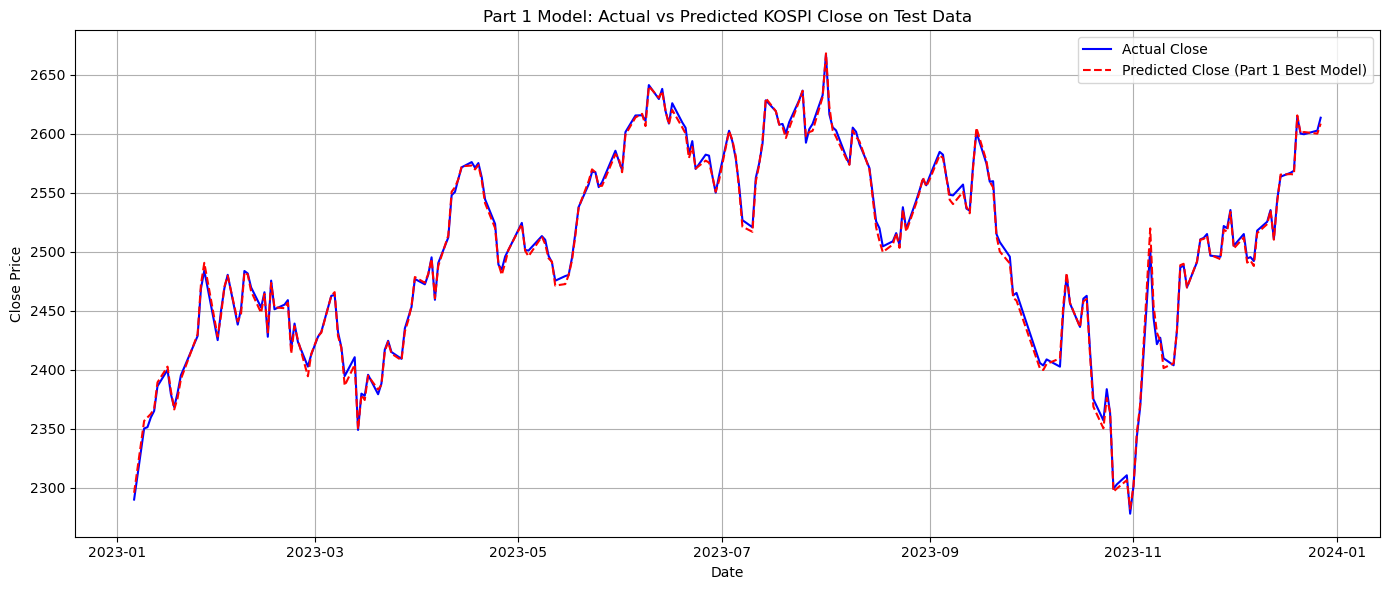

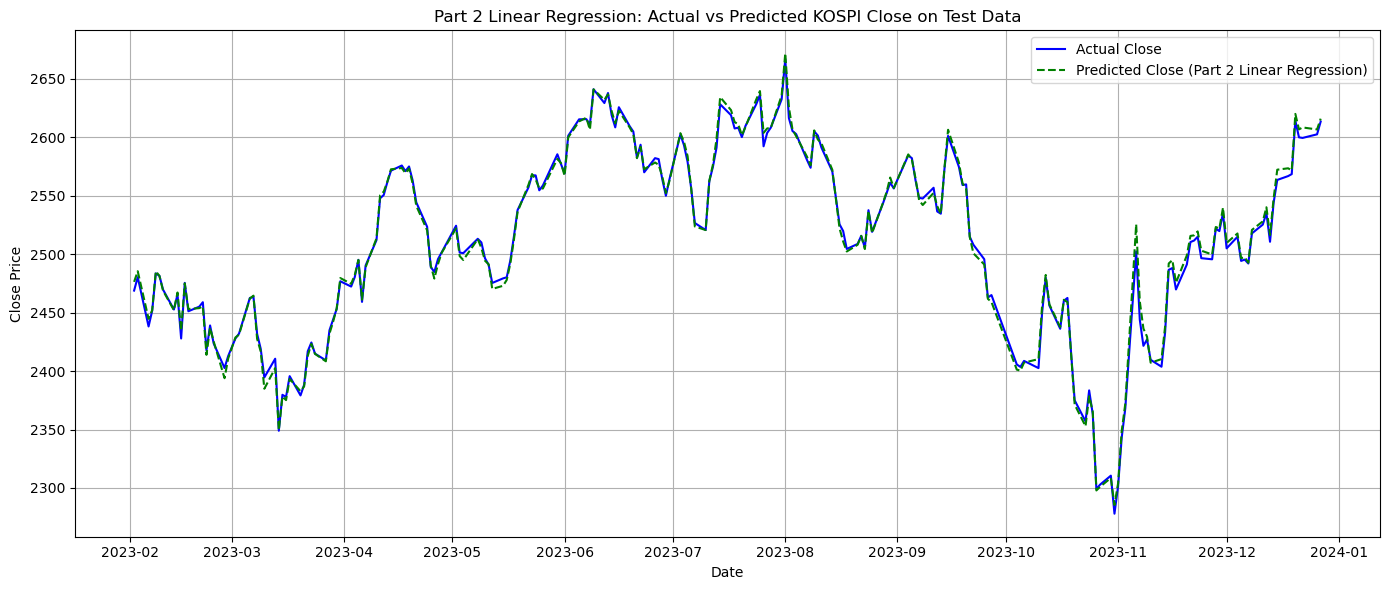

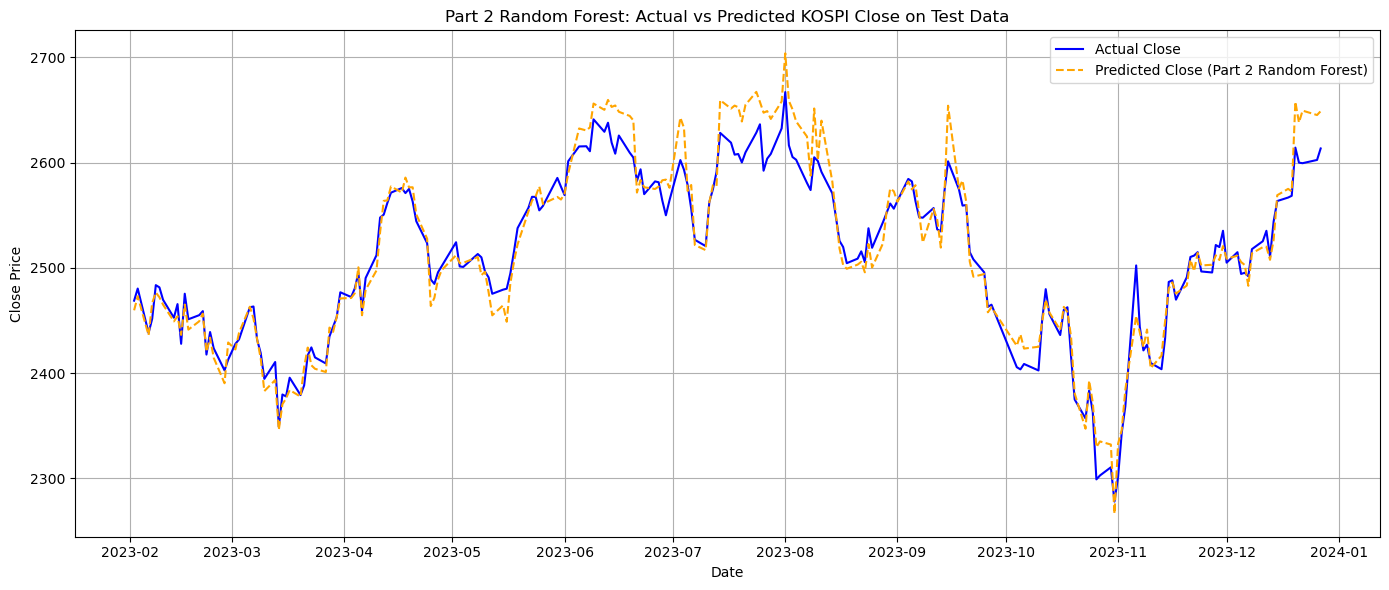

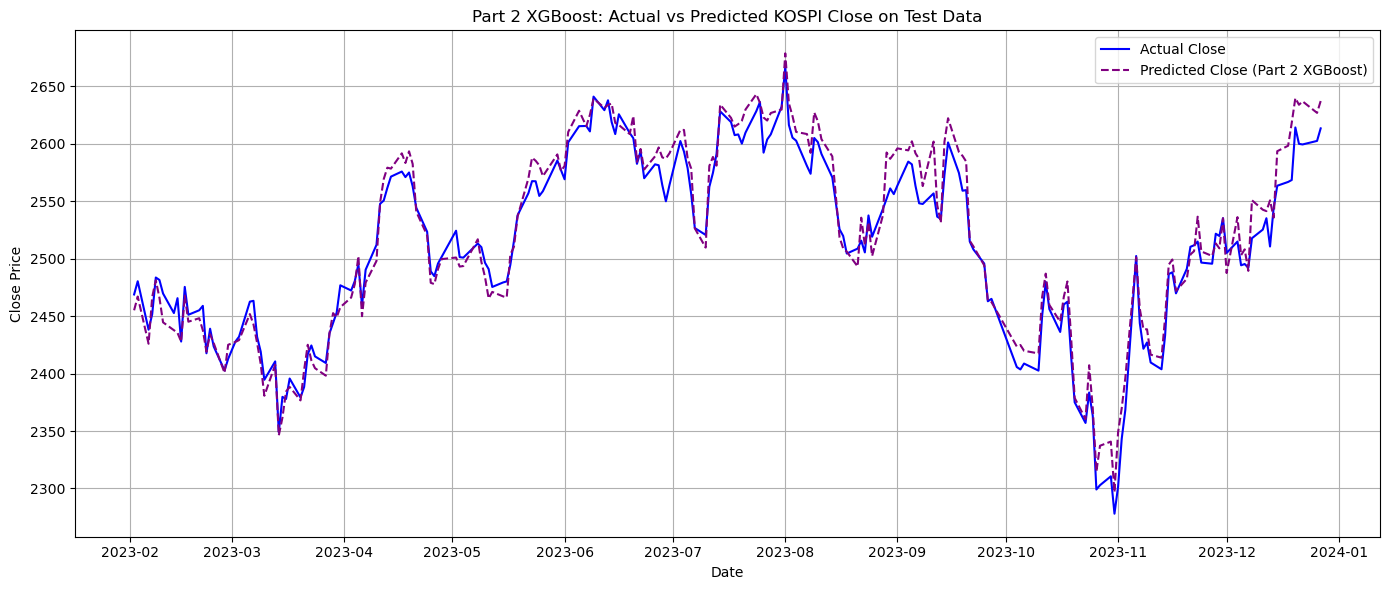

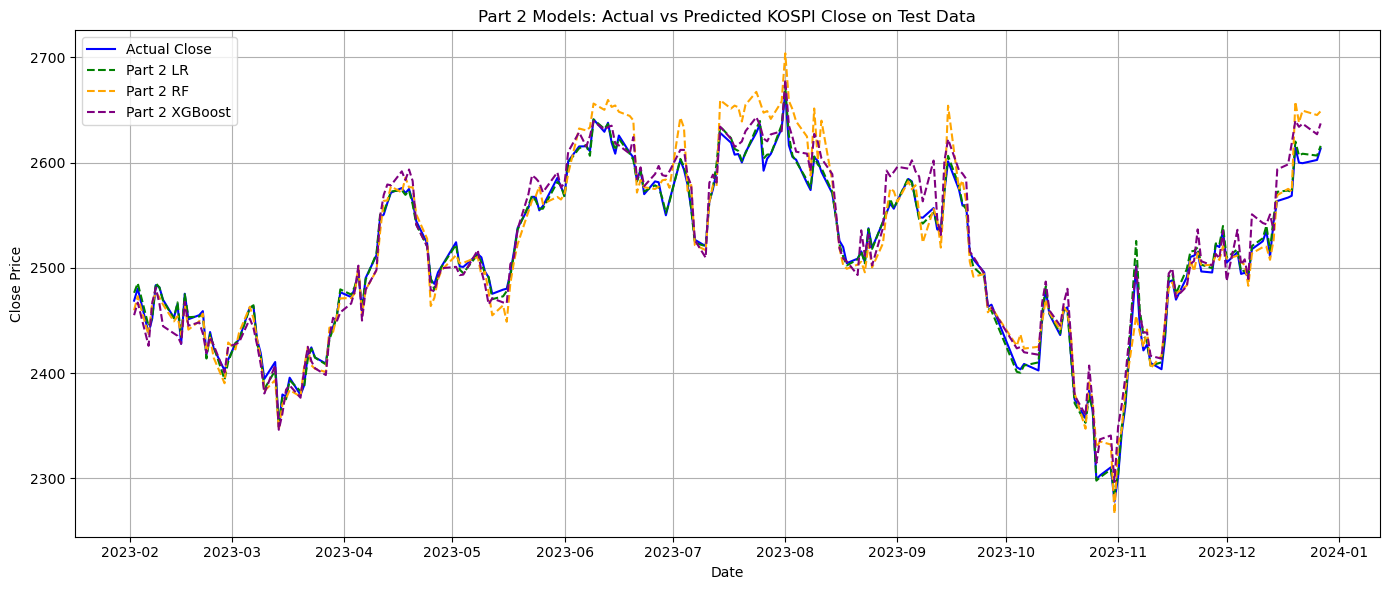

In [68]:
import matplotlib.pyplot as plt
import pandas as pd # 필요하다면 임포트


# Visualize the entire test period
plot_df_part1 = df_test_part1_final.copy()
plot_df_part2 = df_test_part2_final.copy()


# Visualize Part 1 Best Model Prediction Results 
plt.figure(figsize=(14, 6))
plt.plot(plot_df_part1.index, plot_df_part1['Close'], label='Actual Close', color='blue')
# Use the prediction result column for Part 1
plt.plot(plot_df_part1.index, plot_df_part1['Predicted_Close_Part1'], label=f'Predicted Close (Part 1 Best Model)', color='red', linestyle='--')

plt.title('Part 1 Model: Actual vs Predicted KOSPI Close on Test Data')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Visualize Part  Best Model Prediction Results 

# Part 2 Linear Regression Prediction Result
plt.figure(figsize=(14, 6))
plt.plot(plot_df_part2.index, plot_df_part2['Close'], label='Actual Close', color='blue')
plt.plot(plot_df_part2.index, plot_df_part2['Predicted_Close_Part2_LinearRegression'], label='Predicted Close (Part 2 Linear Regression)', color='green', linestyle='--')

plt.title('Part 2 Linear Regression: Actual vs Predicted KOSPI Close on Test Data')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Part 2 Random Forest Prediction Result
plt.figure(figsize=(14, 6))
plt.plot(plot_df_part2.index, plot_df_part2['Close'], label='Actual Close', color='blue')
plt.plot(plot_df_part2.index, plot_df_part2['Predicted_Close_Part2_RandomForest'], label='Predicted Close (Part 2 Random Forest)', color='orange', linestyle='--')

plt.title('Part 2 Random Forest: Actual vs Predicted KOSPI Close on Test Data')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Part 2 XGBoost Prediction Result
plt.figure(figsize=(14, 6))
plt.plot(plot_df_part2.index, plot_df_part2['Close'], label='Actual Close', color='blue')
plt.plot(plot_df_part2.index, plot_df_part2['Predicted_Close_Part2_XGBoost'], label='Predicted Close (Part 2 XGBoost)', color='purple', linestyle='--')

plt.title('Part 2 XGBoost: Actual vs Predicted KOSPI Close on Test Data')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#  Part 2 models together on one graph
plt.figure(figsize=(14, 6))
plt.plot(plot_df_part2.index, plot_df_part2['Close'], label='Actual Close', color='blue')
plt.plot(plot_df_part2.index, plot_df_part2['Predicted_Close_Part2_LinearRegression'], label='Part 2 LR', color='green', linestyle='--')
plt.plot(plot_df_part2.index, plot_df_part2['Predicted_Close_Part2_RandomForest'], label='Part 2 RF', color='orange', linestyle='--')
plt.plot(plot_df_part2.index, plot_df_part2['Predicted_Close_Part2_XGBoost'], label='Part 2 XGBoost', color='purple', linestyle='--')
plt.title('Part 2 Models: Actual vs Predicted KOSPI Close on Test Data')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()